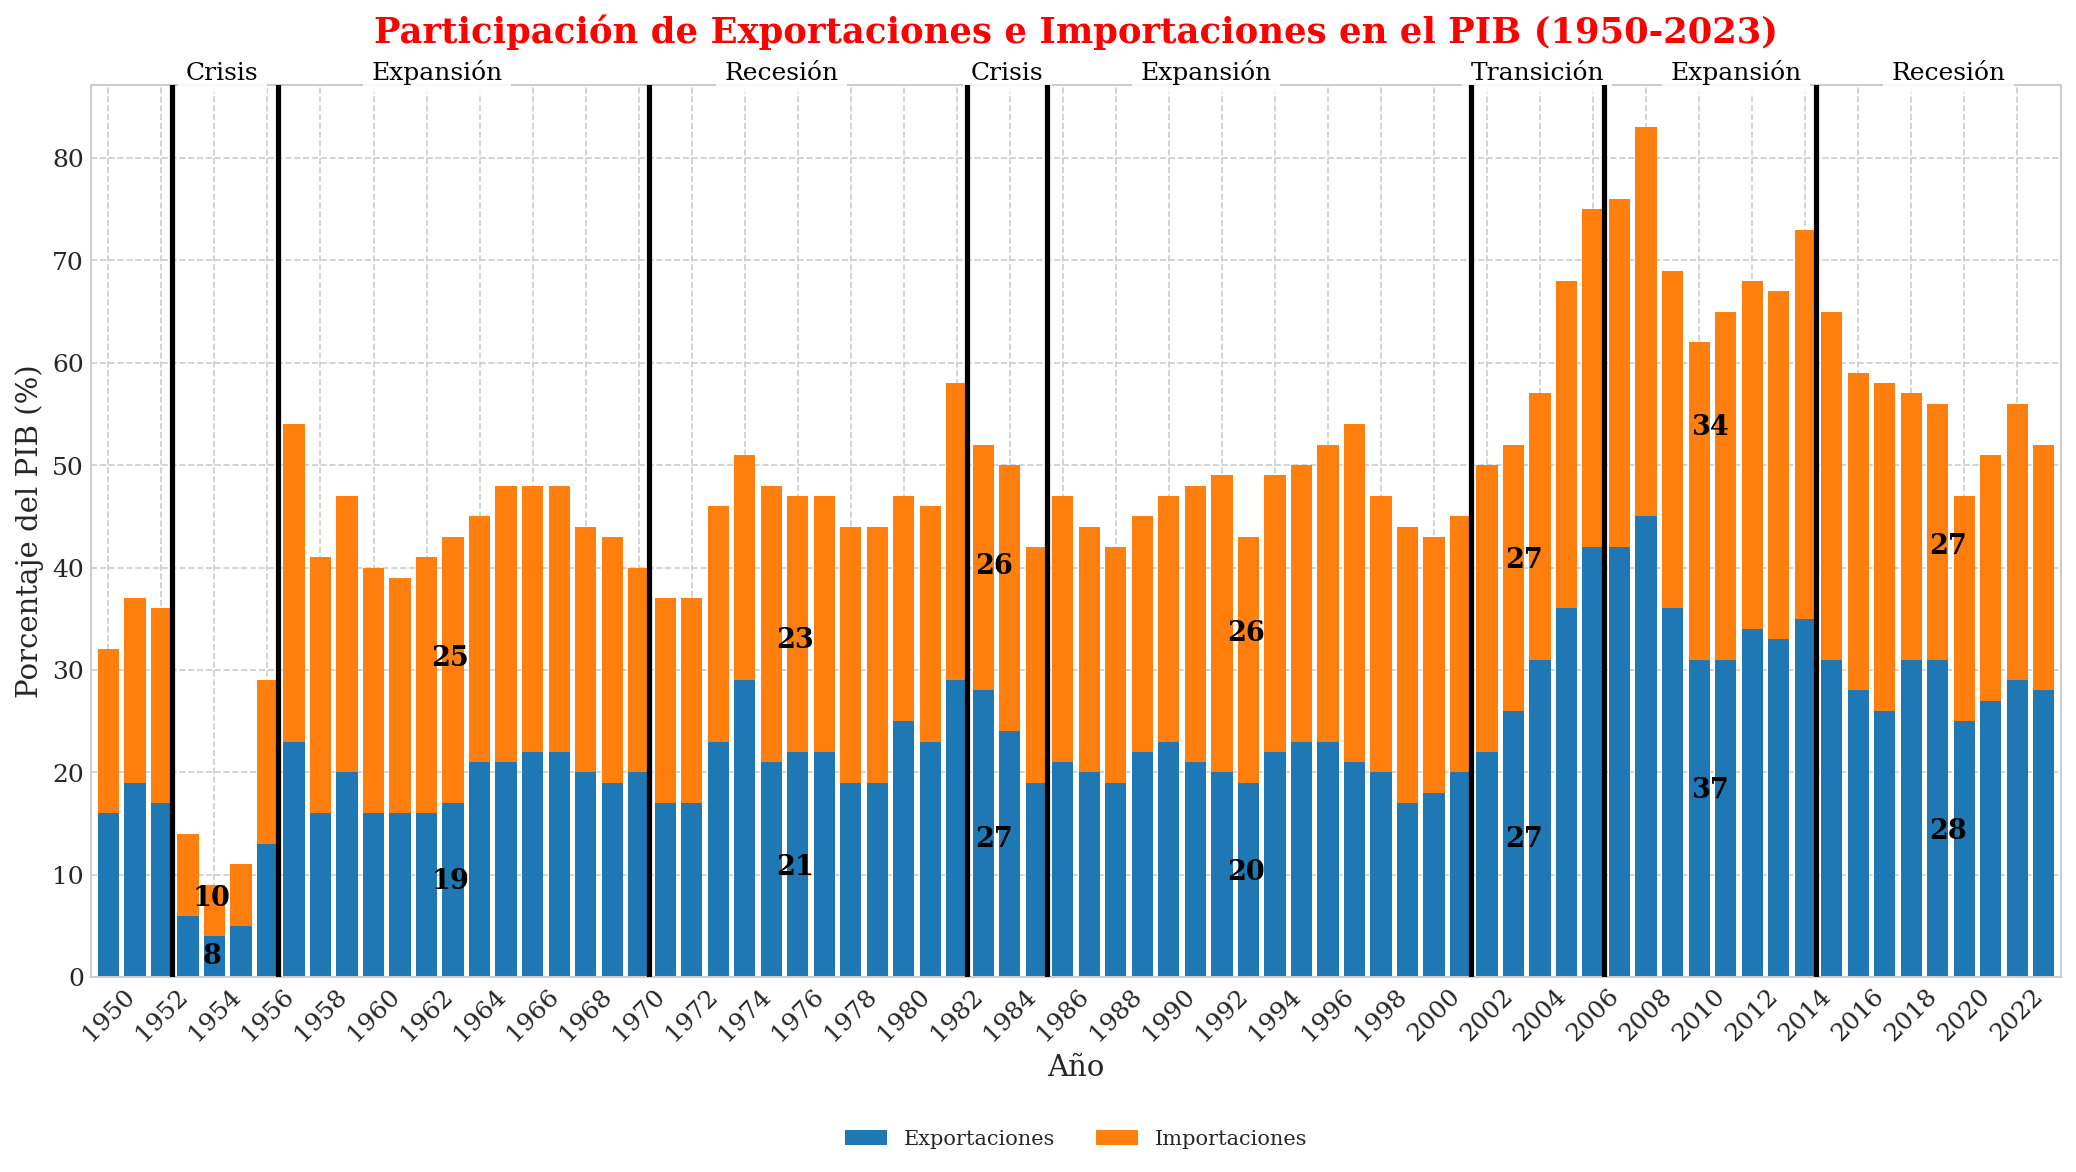

Gráfico guardado en: /home/navi/Desktop/archivos/DS/eco/Proyecto_macro/assets/tesis/serie_completa/participacion_x_m_pib/participacion_exportaciones_importaciones_pib.png


In [14]:
# ───────────────────────────── IMPORTS ──────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import os
import numpy as np
import sys

# IMPORTANTE: Importación correcta para barplot
from func_auxiliares.config import *
from func_auxiliares.graficos_utils import (
    set_style,                    # Estilo corporativo
    plot_stacked_bar,            # 🔑 Función principal para barras apiladas
    add_hitos_barras,            # 🔑 Hitos específicos para barplot
    add_cycle_means_barras,      # 🔑 Medias por ciclo para barplot
    adjust_cycles,               # Ajustar ciclos al DataFrame
)

# Configuración de salida
OUTPUT_DIR = ASSETS_DIR / "serie_completa" / "participacion_x_m_pib"
os.makedirs(OUTPUT_DIR, exist_ok=True)
set_style()

# ── Carga de datos ────────────────────────────────────────────
with sqlite3.connect(str(DB_PATH)) as conn:
    df = pd.read_sql_query("SELECT * FROM participacion_x_m_pib ORDER BY año", conn)

df.set_index("año", inplace=True)

# ── Definir componentes a graficar ───────────────────────────
componentes = [
    ("x", "Exportaciones"),
    ("m", "Importaciones"),
]

# ── Extraer columnas para cálculos ───────────────────────────
cols = [col for col, _ in componentes]

# Los datos ya están en porcentaje según la documentación
# Pero necesitamos crear un DataFrame donde cada fila sume 100%
# para el barplot apilado. Calculamos el total de comercio exterior.
df_pct = df[cols].copy()

# ── Ajustar ciclos al DataFrame actual ───────────────────────
cycles_adj = adjust_cycles(df, CYCLES)

# ── Calcular estadísticas por ciclo ──────────────────────────
cycle_stats = {
    name: df_pct.loc[sl, cols].mean().to_dict()
    for name, sl in cycles_adj.items()
}

# ── Configuración de Offsets Específicos para Barplot ────────
# A) Offsets para hitos verticales en barplot
hitos_offset = {
    1952: (0, 1),
    1956: (0, 1),
    1970: (0, 1),
    1982: (0, 1),
    1985: (0, 1),
    2001: (0, 1),
    2006: (0, 1),
    2014: (0, 1)
}

# B) Posición horizontal del texto de hitos
hitos_text_x = {
    1952: 1.9,
    1956: 6,
    1970: 5,
    1982: 1.5,
    1985: 6,
    2001: 2.5,
    2006: 5,
    2014: 5
}

# C) Offsets para medias por ciclo
MEAN_OFFSETS_BY_NAME = {
    "Crisis 52-55": {
        'x': (0.0, -2),
        'm': (0.0, -5)
    }
}

# ── Crear el gráfico base de barras apiladas ─────────────────
fig, ax = plot_stacked_bar(
    df_pct,                       # DataFrame con porcentajes
    series=componentes,           # Lista de tuplas (columna, etiqueta)
    title="Participación de Exportaciones e Importaciones en el PIB (1950-2023)",
    legend_ncol=2,               # Número de columnas en la leyenda
    figsize=(14, 8),             # Tamaño de la figura
    xlabel="Año",                # Etiqueta del eje X
    ylabel="Porcentaje del PIB (%)"      # Etiqueta del eje Y
)

# ── Líneas verticales de hitos (específicas para barplot) ─────
add_hitos_barras(
    ax, 
    df.index,           # Índice temporal (años)
    hitos_v,            # Diccionario de hitos de config.py
    hitos_offset,       # Offsets verticales
    hitos_text_x        # Posiciones horizontales del texto
)

# ── Medias por ciclo (específicas para barplot) ───────────────
add_cycle_means_barras(
    ax,
    index=list(df.index),        # Secuencia de años
    cycle_slices=cycles_adj,     # Diccionario nombre → slice
    cycle_stats=cycle_stats,     # Diccionario nombre → {col: media}
    cols=cols,                   # Orden de apilado de componentes
    offsets=MEAN_OFFSETS_BY_NAME  # Offsets específicos
)

# ── Finalizar y guardar ──────────────────────────────────────
plt.tight_layout()

# Guardar en formato PNG de alta resolución
out_path = os.path.join(OUTPUT_DIR, "participacion_exportaciones_importaciones_pib.png")
plt.savefig(out_path, dpi=300)
plt.show()

print(f"Gráfico guardado en: {out_path}")

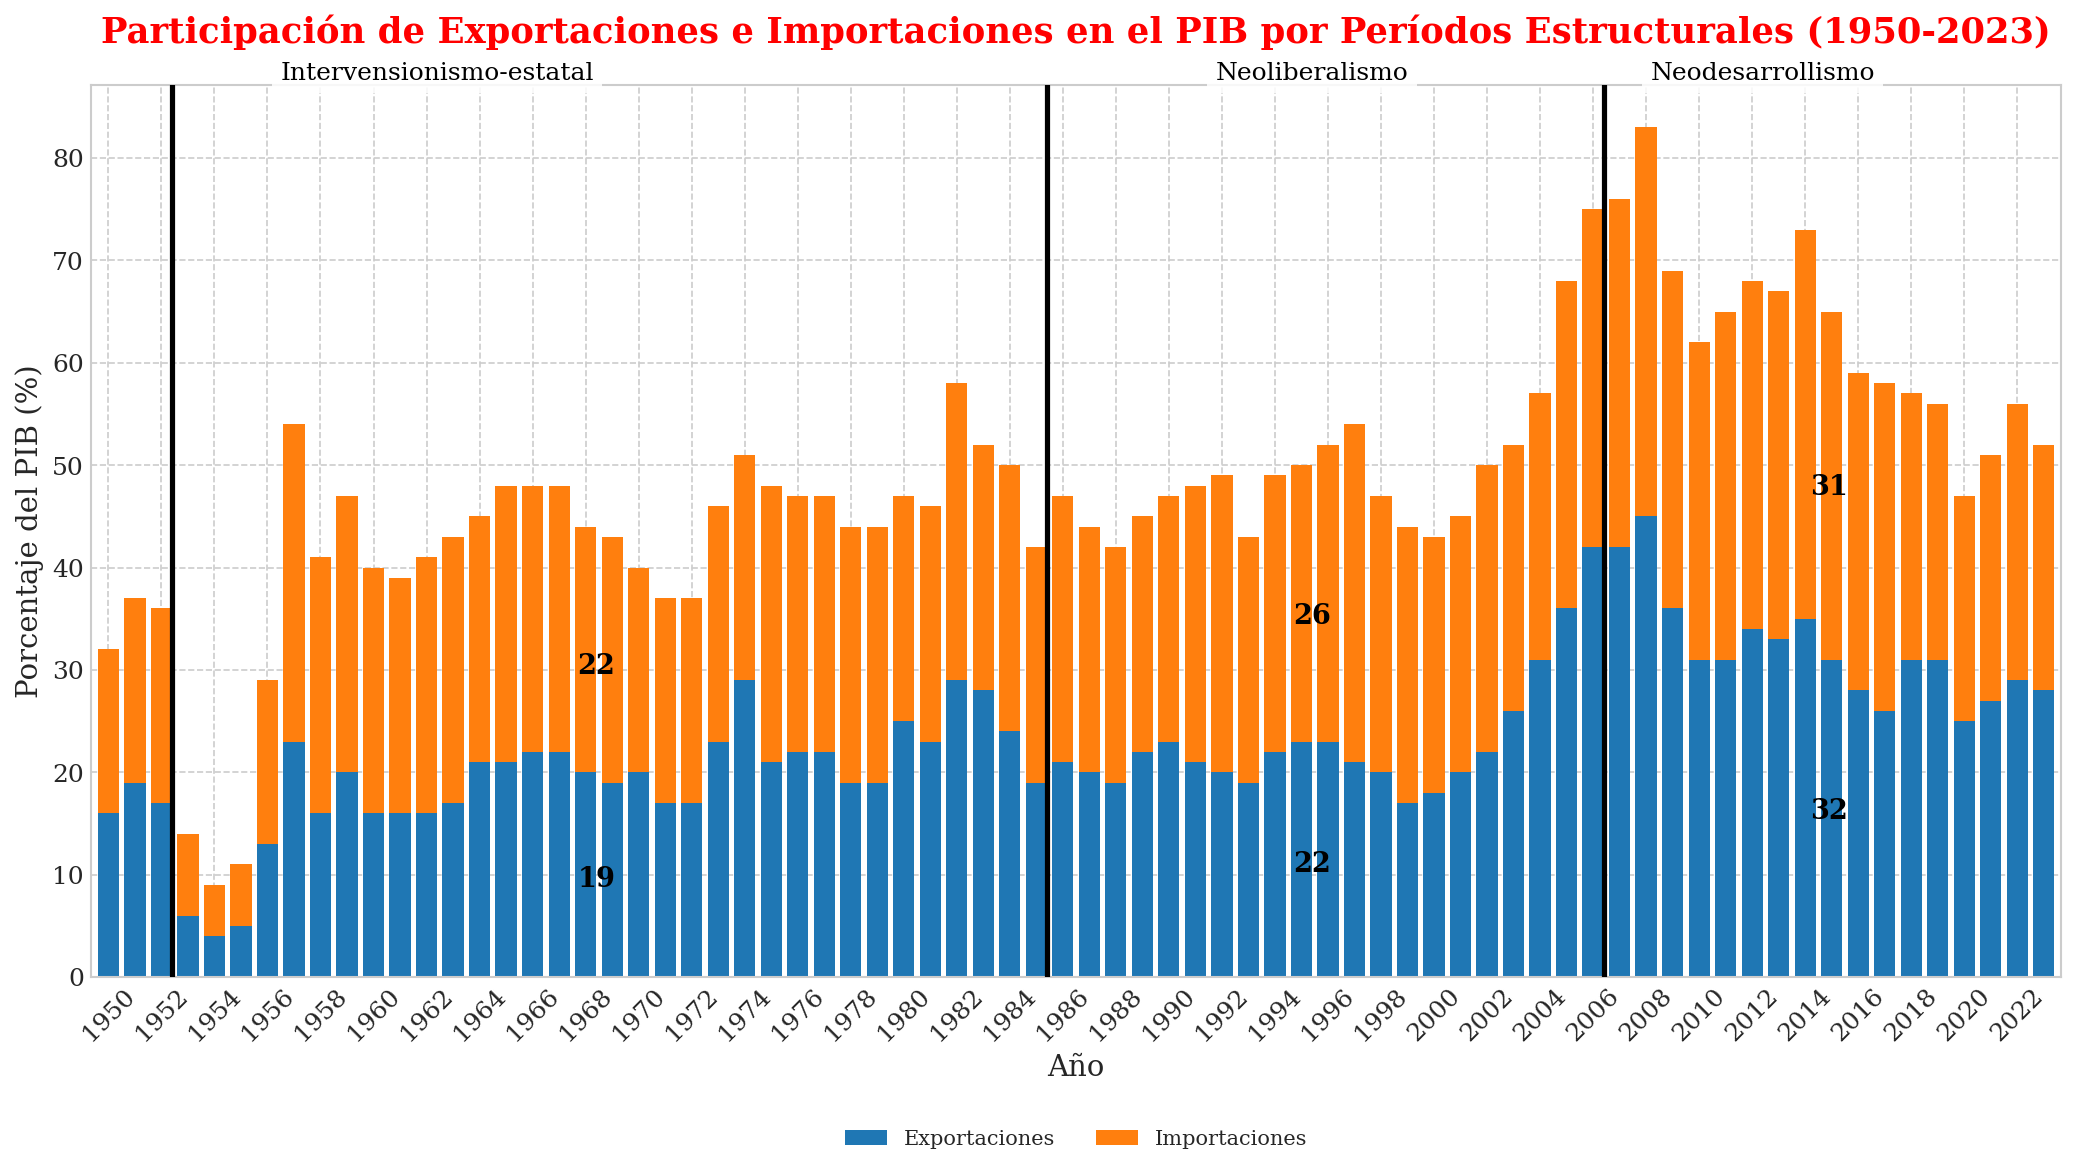

Gráfico de períodos estructurales guardado en: /home/navi/Desktop/archivos/DS/eco/Proyecto_macro/assets/tesis/serie_completa/participacion_x_m_pib/participacion_exportaciones_importaciones_pib_periodos.png


In [9]:
# ── GRÁFICA DE PERÍODOS ESTRUCTURALES ────────────────────────────────

# Usar CYCLES_PERIODOS para vista macro
cycles_periodos = adjust_cycles(df, CYCLES_PERIODOS)
cycle_stats_periodos = {
    name: df_pct.loc[sl, cols].mean().to_dict()
    for name, sl in cycles_periodos.items()
}

# ── Configuración de offsets para períodos estructurales ─────────────
# Hitos simplificados (solo cambios estructurales)
hitos_offset_periodos = {
    1952: (0, 1),
    1985: (0, 1),
    2006: (0, 1),
}

hitos_text_x_periodos = {
    1952: 10,
    1985: 10,
    2006: 6
}
# Offsets para medias por período estructural
MEAN_OFFSETS_BY_NAME_PERIODOS = {

}

# Componentes a omitir (ninguno en este caso)
SKIP_MEANS_BY_NAME_PERIODOS = {
    "Intervensionismo-estatal 52-84": set(),
    "Neoliberalismo 85-05": set(),
    "Neodesarrollismo 06-24": set()
}

# ── Crear el gráfico de períodos estructurales ──────────────────────
fig, ax = plot_stacked_bar(
    df_pct,
    series=componentes,
    title="Participación de Exportaciones e Importaciones en el PIB por Períodos Estructurales (1950-2023)",
    legend_ncol=2,
    figsize=(14, 8),
    xlabel="Año",
    ylabel="Porcentaje del PIB (%)"
)

# ── Añadir hitos de períodos estructurales ───────────────────────────
add_hitos_barras(
    ax, 
    df.index, 
    hitos_v_periodos,  # Usar hitos de períodos estructurales
    hitos_offset_periodos, 
    hitos_text_x_periodos
)

# ── Añadir medias por período estructural ────────────────────────────
add_cycle_means_barras(
    ax,
    index=list(df.index),
    cycle_slices=cycles_periodos,
    cycle_stats=cycle_stats_periodos,
    cols=cols,
    offsets=MEAN_OFFSETS_BY_NAME_PERIODOS,
    skip=SKIP_MEANS_BY_NAME_PERIODOS
)

# ── Finalizar y guardar gráfica de períodos ──────────────────────────
plt.tight_layout()
out_path_periodos = os.path.join(OUTPUT_DIR, "participacion_exportaciones_importaciones_pib_periodos.png")
plt.savefig(out_path_periodos, dpi=300)
plt.show()

print(f"Gráfico de períodos estructurales guardado en: {out_path_periodos}")

In [10]:
df

,x,m
año,,
1950,16.0,16.0
1951,19.0,18.0
1952,17.0,19.0
1953,6.0,8.0
1954,4.0,5.0
...,...,...
2019,31.0,25.0
2020,25.0,22.0
2021,27.0,24.0
